# Covariance Matrix

The covariance matrix summarises how a set of variables vary together: the diagonal holds each variable's own variance, and the off-diagonal entries hold the pairwise covariances — positive when two variables tend to move together, negative when they move oppositely, and near zero when they're roughly independent.

$$
\Sigma =
\begin{bmatrix}
\text{Var}(X_1) & \text{Cov}(X_1, X_2) & \ldots & \text{Cov}(X_1, X_n) \\
\text{Cov}(X_2, X_1) & \text{Var}(X_2) & \ldots & \text{Cov}(X_2, X_n) \\
\vdots & \vdots & \ddots & \vdots \\
\text{Cov}(X_n, X_1) & \text{Cov}(X_n, X_2) & \ldots & \text{Var}(X_n) \\
\end{bmatrix}
$$

This notebook covers:
1. The mathematical definition and how it's used to simulate correlated data
2. Why it matters for statistics, regression, and finance
3. A comprehensive worked example: **PCA-based dimensionality reduction for a stock portfolio**

## 1. Definition and Use in Simulation

For random variables $X_1, \ldots, X_n$ with means $\mu_1, \ldots, \mu_n$, the covariance between any pair is:

$$\text{Cov}(X_i, X_j) = E[(X_i - \mu_i)(X_j - \mu_j)] = E[X_iX_j] - \mu_i\mu_j$$

Collecting all pairwise covariances into an $n\times n$ symmetric matrix $\Sigma$ gives the covariance matrix shown above.

**Why it matters for simulation:** a multivariate normal distribution is fully specified by its mean vector $\mu$ and covariance matrix $\Sigma$. Sampling from $\mathcal{N}(\mu, \Sigma)$ — rather than sampling each variable independently — is what lets a simulation reproduce the *correlations* present in real data, not just each variable's individual spread. This is central to Monte Carlo simulation of correlated systems (e.g. multiple stocks that tend to move together).

In [1]:
import numpy as np

# Specify a mean vector and covariance matrix, then sample from the
# corresponding multivariate normal distribution
mean = np.array([1, 2, 3])
cov_matrix = np.array([
    [1.0, 0.5, 0.2],
    [0.5, 2.0, 0.7],
    [0.2, 0.7, 3.0],
])

samples = np.random.multivariate_normal(mean, cov_matrix, size=1000)

print("Sample mean:            ", np.mean(samples, axis=0).round(3))
print("Sample covariance:\n", np.cov(samples, rowvar=False).round(3))

Sample mean:             [1.005 2.006 3.019]
Sample covariance:
 [[0.978 0.469 0.205]
 [0.469 1.832 0.614]
 [0.205 0.614 3.061]]


As the sample size grows, the sample mean and sample covariance converge to the values used to generate the data — this is exactly the Monte Carlo idea from the previous notebook, applied to a multivariate distribution.

In [2]:
# Monte Carlo simulation using a covariance matrix: repeat the sampling
# many times and look at how a downstream statistic behaves
mean = np.array([1, 2])
cov_matrix = np.array([[1.0, 0.5], [0.5, 2.0]])

num_simulations = 1000
num_samples = 100

results = []
for _ in range(num_simulations):
    samples = np.random.multivariate_normal(mean, cov_matrix, num_samples)
    results.append(samples[:, 0].mean() + samples[:, 1].mean())

print(f"Simulation mean:                {np.mean(results):.4f}")
print(f"Simulation standard deviation:  {np.std(results):.4f}")

Simulation mean:                2.9955
Simulation standard deviation:  0.2023


### Matching Simulated Data to a Real Dataset

Given real data, its sample mean and covariance matrix can be used to generate *simulated* data with the same first- and second-order statistics — useful for stress-testing a model on synthetic-but-realistic data.

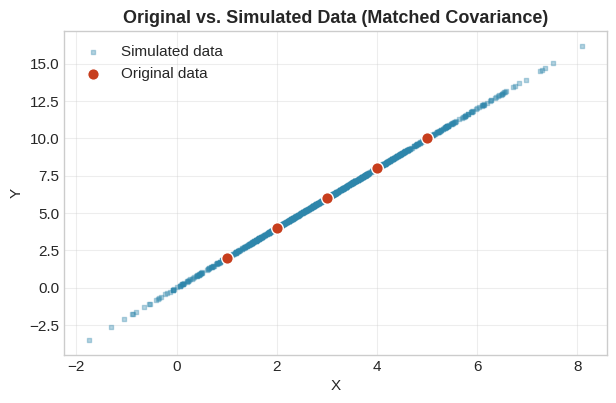

In [3]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'grid.alpha': 0.35,
})

# A small "real" dataset
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

mean = np.array([x.mean(), y.mean()])
cov_matrix = np.cov(x, y)

simulated = np.random.multivariate_normal(mean, cov_matrix, 1000).T

fig, ax = plt.subplots()
ax.scatter(simulated[0], simulated[1], color='#2E86AB', marker='s', s=8, alpha=0.35, label='Simulated data')
ax.scatter(x, y, color='#C73E1D', s=70, edgecolor='white', zorder=3, label='Original data')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Original vs. Simulated Data (Matched Covariance)')
ax.legend()
plt.show()

Fitting a regression line to simulated correlated data shows the same idea from the modeling side: the covariance structure alone is enough to recover the linear relationship between variables.

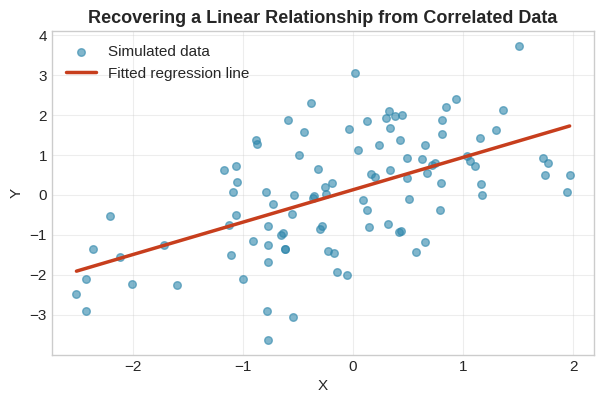

In [4]:
from sklearn.linear_model import LinearRegression

np.random.seed(0)
mean = [0, 0]
cov_matrix = [[1, 0.8], [0.8, 2]]
simulated = np.random.multivariate_normal(mean, cov_matrix, 100).T
x, y = simulated[0], simulated[1]

model = LinearRegression().fit(x.reshape(-1, 1), y)
x_range = np.linspace(x.min(), x.max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))

fig, ax = plt.subplots()
ax.scatter(x, y, color='#2E86AB', alpha=0.6, s=30, label='Simulated data')
ax.plot(x_range, y_pred, color='#C73E1D', linewidth=2.5, label='Fitted regression line')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Recovering a Linear Relationship from Correlated Data')
ax.legend()
plt.show()

## 2. Why the Covariance Matrix Matters

- **Relationship strength** — sign and magnitude of each entry show how strongly two variables move together.
- **Variance** — the diagonal gives each variable's variance directly (its square root is the standard deviation).
- **Multivariate normal distributions** — fully determined by mean vector and covariance matrix.
- **Principal Component Analysis (PCA)** — the covariance matrix's eigenvectors are the directions of maximum variance ("principal components"), and its eigenvalues are the variance captured along each direction. This is the basis for dimensionality reduction, explored in depth below.
- **Linear regression** — coefficient estimation and significance testing both rely on covariance relationships between predictors and the response.
- **Portfolio theory** — the covariance matrix of asset returns drives risk and diversification: two assets with low or negative covariance reduce a portfolio's overall risk more than two assets that move in lockstep.

## 3. Worked Example: PCA for Stock Portfolio Dimensionality Reduction

A portfolio of many stocks has a large, dense covariance matrix — most stocks are correlated with most other stocks through shared market and sector effects. **Principal Component Analysis (PCA)** re-expresses the same information in terms of a small number of uncorrelated "factors" (the principal components), ordered by how much of the total variance each one explains.

This section builds a synthetic 10-stock universe with realistic sector correlation, then:
1. Visualises the covariance/correlation structure and the PCA decomposition itself (diagrams),
2. Tracks the resulting factors as time series,
3. Tests how well a *low-dimensional* factor model reconstructs returns **out of sample**,
4. Runs a **rolling-window PCA** to see how the dominant factor's importance changes over time (a classic early-warning signal for market stress).

### 3.1 Simulating a Correlated Stock Universe

Ten stocks are grouped into three "sectors" (Tech, Energy, Healthcare). Returns within a sector are simulated with higher pairwise correlation than returns across sectors — a simplified but realistic structure for testing dimensionality reduction.

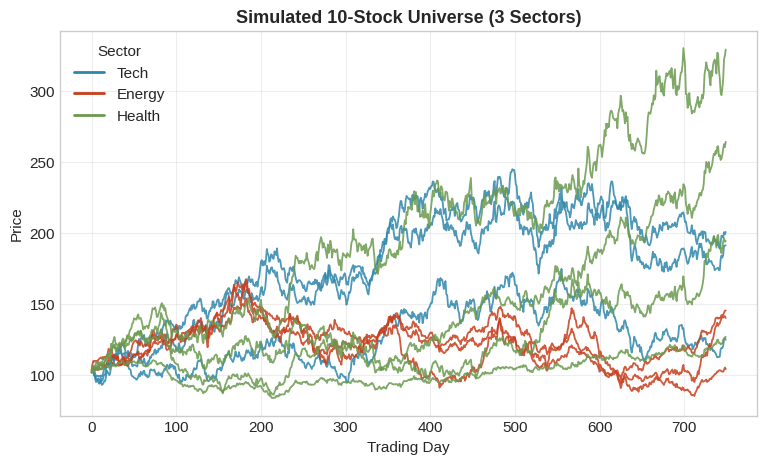

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

tickers = ['TCH1', 'TCH2', 'TCH3', 'ENG1', 'ENG2', 'ENG3', 'HLT1', 'HLT2', 'HLT3', 'HLT4']
sectors = ['Tech']*3 + ['Energy']*3 + ['Health']*4
n_assets = len(tickers)
SECTOR_COLORS = {'Tech': '#2E86AB', 'Energy': '#C73E1D', 'Health': '#6A994E'}

# Build a block-correlated correlation matrix: high within-sector, low across sectors
corr = np.full((n_assets, n_assets), 0.15)
sector_idx = {s: [i for i, sec in enumerate(sectors) if sec == s] for s in set(sectors)}
for idxs in sector_idx.values():
    for i in idxs:
        for j in idxs:
            corr[i, j] = 0.75
np.fill_diagonal(corr, 1.0)

vols = rng.uniform(0.15, 0.35, n_assets)          # annualised volatility per stock
cov_annual = np.outer(vols, vols) * corr           # annual covariance matrix
mu_annual = rng.uniform(0.04, 0.12, n_assets)      # annual expected return per stock

# Simulate 3 years of daily returns from a multivariate normal
n_days = 750
dt = 1 / 252
daily_mean = mu_annual * dt
daily_cov = cov_annual * dt

returns = rng.multivariate_normal(daily_mean, daily_cov, size=n_days)
prices = 100 * np.exp(np.cumsum(returns, axis=0))

fig, ax = plt.subplots(figsize=(9, 5))
for i, ticker in enumerate(tickers):
    ax.plot(prices[:, i], color=SECTOR_COLORS[sectors[i]], linewidth=1.3, alpha=0.85,
            label=ticker if i in [0, 3, 6] else None)
ax.set_xlabel('Trading Day'); ax.set_ylabel('Price')
ax.set_title('Simulated 10-Stock Universe (3 Sectors)')
handles = [plt.Line2D([0], [0], color=c, lw=2) for c in SECTOR_COLORS.values()]
ax.legend(handles, SECTOR_COLORS.keys(), title='Sector')
plt.show()

### 3.2 Covariance Structure (Diagram)

The correlation heatmap makes the sector-block structure explicit — this is exactly the kind of redundancy PCA is designed to compress into a handful of factors.

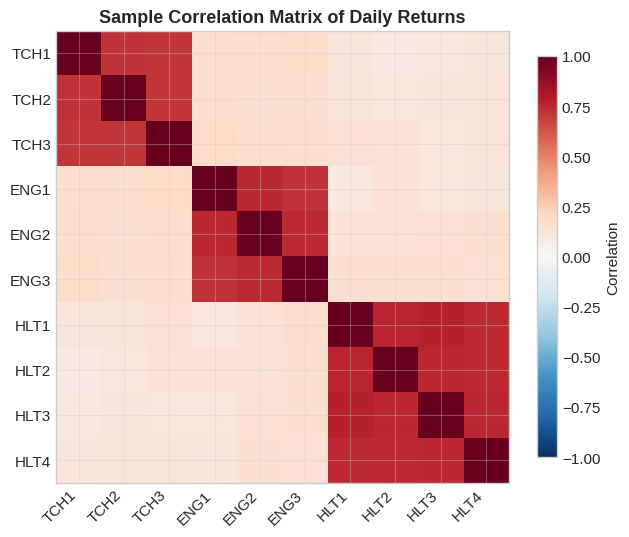

In [6]:
sample_corr = np.corrcoef(returns, rowvar=False)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(sample_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_assets)); ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.set_yticks(range(n_assets)); ax.set_yticklabels(tickers)
ax.set_title('Sample Correlation Matrix of Daily Returns')
fig.colorbar(im, ax=ax, label='Correlation', shrink=0.85)
plt.tight_layout()
plt.show()

### 3.3 Principal Component Analysis

PCA is applied to the standardized returns. The **scree plot** shows how much variance each successive component explains — the steep drop after the first couple of components is the visual signature of the sector structure built into the simulation.

Components needed to explain 90% of variance: 6 (out of 10 stocks)


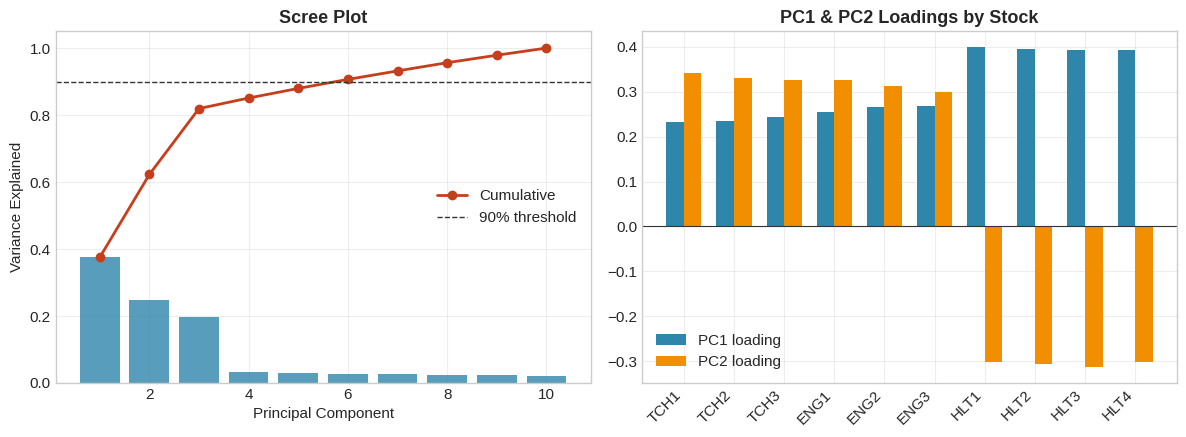

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

returns_std = StandardScaler().fit_transform(returns)

pca = PCA()
pca.fit(returns_std)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.bar(range(1, n_assets + 1), explained, color='#2E86AB', alpha=0.8)
ax.plot(range(1, n_assets + 1), cumulative, 'o-', color='#C73E1D', linewidth=2, label='Cumulative')
ax.axhline(0.9, color='#333333', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Variance Explained')
ax.set_title('Scree Plot')
ax.legend()

# Loadings of the first two PCs — shows which stocks drive each factor
ax = axes[1]
x_pos = np.arange(n_assets)
width = 0.35
colors = [SECTOR_COLORS[s] for s in sectors]
ax.bar(x_pos - width/2, pca.components_[0], width, color='#2E86AB', label='PC1 loading')
ax.bar(x_pos + width/2, pca.components_[1], width, color='#F18F01', label='PC2 loading')
ax.set_xticks(x_pos); ax.set_xticklabels(tickers, rotation=45, ha='right')
ax.axhline(0, color='#333333', linewidth=0.8)
ax.set_title('PC1 & PC2 Loadings by Stock')
ax.legend()

plt.tight_layout()
plt.show()

n_for_90 = np.searchsorted(cumulative, 0.9) + 1
print(f"Components needed to explain 90% of variance: {n_for_90} (out of {n_assets} stocks)")

### 3.4 Principal Components as Time Series

Each principal component score is itself a time series — effectively a synthetic "factor" that summarises how a cluster of stocks moved on a given day. PC1 typically tracks broad market-wide movement; PC2 and beyond pick up sector-specific effects.

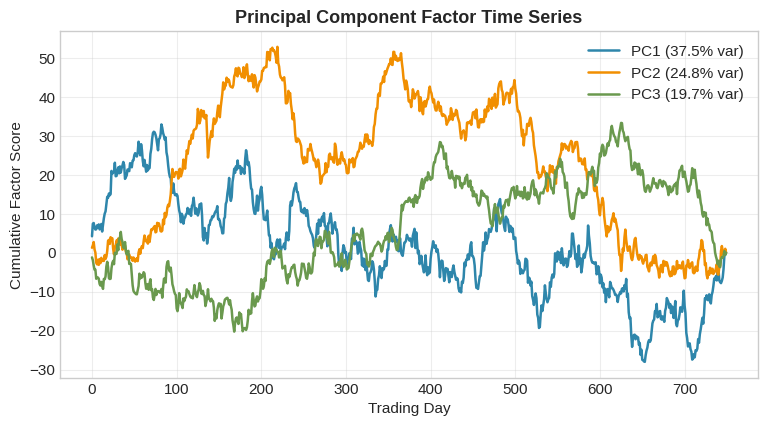

In [8]:
pc_scores = pca.transform(returns_std)
pc_cum = np.cumsum(pc_scores[:, :3], axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors3 = ['#2E86AB', '#F18F01', '#6A994E']
for i in range(3):
    ax.plot(pc_cum[:, i], color=colors3[i], linewidth=1.8,
            label=f'PC{i+1} ({explained[i]*100:.1f}% var)')
ax.set_xlabel('Trading Day'); ax.set_ylabel('Cumulative Factor Score')
ax.set_title('Principal Component Factor Time Series')
ax.legend()
plt.show()

### 3.5 Portfolio Reconstruction and Out-of-Sample Prediction

Here's the practical payoff: instead of tracking all 10 stocks, reconstruct an equal-weighted portfolio's return using only the top $k$ principal components. The **PCA basis is fit on a training period only**, then applied unchanged to a held-out test period — this is what makes the comparison a genuine out-of-sample test, not just a curve fit.

Test-period RMSE with k=3 components: 0.00057
Test-period RMSE with all 10 components: 0.00000


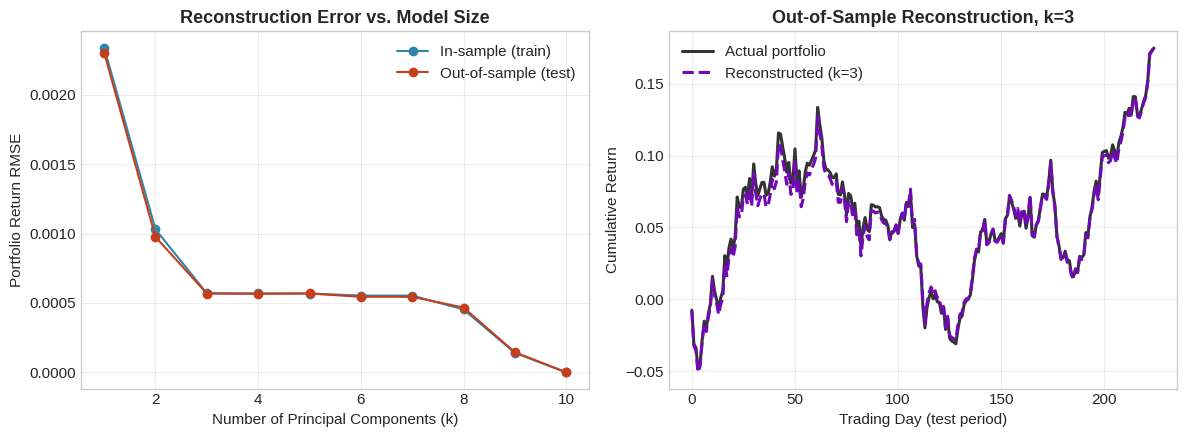

In [9]:
# Train / test split
split = int(n_days * 0.7)
train_returns, test_returns = returns[:split], returns[split:]

scaler = StandardScaler().fit(train_returns)
train_std = scaler.transform(train_returns)
test_std = scaler.transform(test_returns)

weights = np.full(n_assets, 1 / n_assets)   # equal-weighted portfolio
actual_test_portfolio = test_returns @ weights

k_range = range(1, n_assets + 1)
train_errors, test_errors = [], []

for k in k_range:
    pca_k = PCA(n_components=k).fit(train_std)

    # Reconstruct train and test returns using only k components from the TRAIN-fitted basis
    train_recon_std = pca_k.inverse_transform(pca_k.transform(train_std))
    test_recon_std = pca_k.inverse_transform(pca_k.transform(test_std))
    train_recon = scaler.inverse_transform(train_recon_std)
    test_recon = scaler.inverse_transform(test_recon_std)

    train_port_recon = train_recon @ weights
    test_port_recon = test_recon @ weights

    train_errors.append(np.sqrt(np.mean((train_returns @ weights - train_port_recon) ** 2)))
    test_errors.append(np.sqrt(np.mean((actual_test_portfolio - test_port_recon) ** 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(list(k_range), train_errors, 'o-', color='#2E86AB', label='In-sample (train)')
ax.plot(list(k_range), test_errors, 'o-', color='#C73E1D', label='Out-of-sample (test)')
ax.set_xlabel('Number of Principal Components (k)'); ax.set_ylabel('Portfolio Return RMSE')
ax.set_title('Reconstruction Error vs. Model Size')
ax.legend()

# Use a small k (=3) to show actual vs reconstructed cumulative portfolio return, out of sample
k_show = 3
pca_show = PCA(n_components=k_show).fit(train_std)
test_recon_std = pca_show.inverse_transform(pca_show.transform(test_std))
test_recon = scaler.inverse_transform(test_recon_std)
test_port_recon = test_recon @ weights

ax = axes[1]
ax.plot(np.cumsum(actual_test_portfolio), color='#333333', linewidth=2.2, label='Actual portfolio')
ax.plot(np.cumsum(test_port_recon), color='#7209B7', linewidth=2.2, linestyle='--',
        label=f'Reconstructed (k={k_show})')
ax.set_xlabel('Trading Day (test period)'); ax.set_ylabel('Cumulative Return')
ax.set_title(f'Out-of-Sample Reconstruction, k={k_show}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Test-period RMSE with k={k_show} components: {test_errors[k_show-1]:.5f}")
print(f"Test-period RMSE with all {n_assets} components: {test_errors[-1]:.5f}")

### 3.6 Rolling-Window PCA Analysis

Correlation structure isn't static — during market stress, previously distinct stocks and sectors tend to move together, so the variance explained by the *first* principal component spikes. A rolling PCA, refit on a moving window, tracks this directly and is a widely used regime-change / systemic-risk indicator.

To demonstrate it here, a **correlation shock** is injected into the second half of the sample — all stocks briefly become far more correlated, mimicking a crisis period — so the rolling analysis has something real to detect.

Baseline PC1 variance share: 38.5%
Peak PC1 variance share during shock: 89.5%


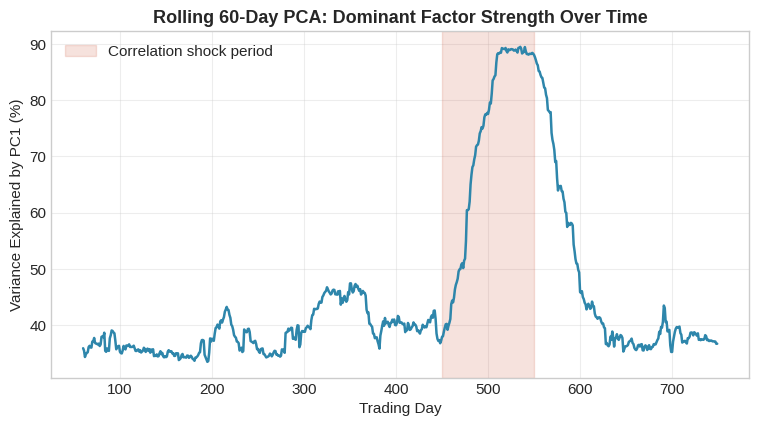

In [10]:
# Inject a temporary correlation shock into a slice of the sample
shock_start, shock_end = 450, 550
shocked_returns = returns.copy()

shock_corr = np.full((n_assets, n_assets), 0.85)
np.fill_diagonal(shock_corr, 1.0)
shock_cov = np.outer(vols, vols) * shock_corr * dt
shock_period_len = shock_end - shock_start
shocked_returns[shock_start:shock_end] = rng.multivariate_normal(
    daily_mean, shock_cov, size=shock_period_len
)

window = 60
rolling_pc1_var = []
rolling_days = []

for end in range(window, n_days):
    window_data = shocked_returns[end - window:end]
    window_std = StandardScaler().fit_transform(window_data)
    pca_roll = PCA(n_components=1).fit(window_std)
    rolling_pc1_var.append(pca_roll.explained_variance_ratio_[0])
    rolling_days.append(end)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rolling_days, np.array(rolling_pc1_var) * 100, color='#2E86AB', linewidth=1.8)
ax.axvspan(shock_start, shock_end, color='#C73E1D', alpha=0.15, label='Correlation shock period')
ax.set_xlabel('Trading Day'); ax.set_ylabel('Variance Explained by PC1 (%)')
ax.set_title(f'Rolling {window}-Day PCA: Dominant Factor Strength Over Time')
ax.legend()
plt.show()

baseline = np.mean(rolling_pc1_var[:shock_start - window])
peak = np.max(rolling_pc1_var)
print(f"Baseline PC1 variance share: {baseline*100:.1f}%")
print(f"Peak PC1 variance share during shock: {peak*100:.1f}%")

### Summary

- The covariance (or correlation) matrix of asset returns fully determines PCA's principal components — the eigenvectors of $\Sigma$.
- A handful of components (here, ~3 of 10) capture most of the portfolio's variance, because real assets share sector- and market-wide risk factors.
- Fitting PCA strictly on a training window and testing reconstruction on a held-out period is what separates a genuine dimensionality-reduction result from overfitting.
- Rolling PCA turns the covariance matrix into a *time-varying* diagnostic: a rising PC1 share is a direct, model-free signal that a portfolio's diversification benefit is eroding.